In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from pathlib import Path
import os
import re

In [2]:
# these horizons is the number of steps were forcasting ahead to

""" the cadence of each file is 12 mins 
so we will forecast 12 min ahead to add a live forecast feature that can be usefule via api 
"""

HORIZONS = {
    "12min": 1,
}


FEATURE_COLS = [
    "TOTUSJH",
    "TOTBSQ",
    "TOTPOT",
    "TOTUSJZ",
    "ABSNJZH",
    "R_VALUE",
]

# these are the features that we need to forecast 

TARGETS = FEATURE_COLS

TIMESTAMP_COL = ["Timestamp"]

LAGS            = list(range(1, 25))   # past 24 steps (4.8 hrs) as input
ROLLING_WINDOWS = [3, 6, 9]
TEST_RATIO      = 0.2

DATA_DIR = Path("../data/dataverse_files/partition3_instances/partition3/FL")

In [3]:

def build_features_for_file(temp_df, feature_cols, lags, rolling_windows):
    #rolling only use prev
    feature_dict = {}

    for feature in feature_cols:
        s = temp_df[feature]

        # lags: past only
        for lag in lags:
            feature_dict[f"{feature}_lag_{lag}"] = s.shift(lag)

        # rolling only past rows
        shifted = s.shift(1)
        for window in rolling_windows:
            feature_dict[f"{feature}_roll_mean_{window}"] = shifted.rolling(window=window, min_periods=1).mean()
            feature_dict[f"{feature}_roll_std_{window}"] = shifted.rolling(window=window, min_periods=1).std()

    return pd.DataFrame(feature_dict, index=temp_df.index)


df_list = []

for file in os.listdir(DATA_DIR):
    if file.endswith(".csv"):
        print(f"Processing file: {file}")
        file_path = DATA_DIR / file

        temp_df = pd.read_csv(file_path, sep="\t")
        temp_df["Timestamp"] = pd.to_datetime(temp_df["Timestamp"], errors="coerce")
        temp_df = temp_df.sort_values("Timestamp").reset_index(drop=True)

        ar_match = re.search(r"_ar(\d+)", file)
        temp_df["active_region"] = int(ar_match.group(1)) if ar_match else pd.NA
        temp_df["source_file"] = file

        # interpolate raw features only
        temp_df[FEATURE_COLS] = (
            temp_df[FEATURE_COLS]
            .interpolate(method="linear", axis=0, limit_direction="both")
            .ffill()
            .bfill()
        )

        # build engineered features all at once
        feat_df = build_features_for_file(
            temp_df=temp_df,
            feature_cols=FEATURE_COLS,
            lags=LAGS,
            rolling_windows=ROLLING_WINDOWS,
        )

        # combine once to get rid of spam warning
        temp_df = pd.concat([temp_df, feat_df], axis=1)

        df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
lag_feature_cols = [
    f"{feature}_lag_{lag}"
    for feature in FEATURE_COLS
    for lag in LAGS
]

rolling_feature_cols = [
    f"{feature}_roll_{stat}_{window}"
    for feature in FEATURE_COLS
    for window in ROLLING_WINDOWS
    for stat in ["mean", "std"]
]

df = df[
    ["Timestamp", "active_region", "source_file"]
    + FEATURE_COLS
    + lag_feature_cols
    + rolling_feature_cols
]

Processing file: M1.0@6861_Primary_ar3311_s2013-10-25T23_48_00_e2013-10-26T11_36_00.csv
Processing file: M1.0@6861_Primary_ar3311_s2013-10-26T00_48_00_e2013-10-26T12_36_00.csv
Processing file: M1.0@6861_Primary_ar3311_s2013-10-26T01_48_00_e2013-10-26T13_36_00.csv
Processing file: M1.0@6861_Primary_ar3311_s2013-10-26T02_48_00_e2013-10-26T14_36_00.csv
Processing file: M1.0@6861_Primary_ar3311_s2013-10-26T03_48_00_e2013-10-26T15_36_00.csv
Processing file: M1.0@6861_Primary_ar3311_s2013-10-26T04_48_00_e2013-10-26T16_36_00.csv
Processing file: M1.0@6861_Primary_ar3311_s2013-10-26T05_48_00_e2013-10-26T17_36_00.csv
Processing file: M1.0@6861_Primary_ar3311_s2013-10-26T06_48_00_e2013-10-26T18_36_00.csv
Processing file: M1.0@6861_Primary_ar3311_s2013-10-26T07_48_00_e2013-10-26T19_36_00.csv
Processing file: M1.0@7047_Primary_ar3376_s2013-11-13T20_00_00_e2013-11-14T07_48_00.csv
Processing file: M1.0@7047_Primary_ar3376_s2013-11-13T21_00_00_e2013-11-14T08_48_00.csv
Processing file: M1.0@7047_Prima

In [4]:
def create_targets(df, feature_cols, horizons):
    df = df.copy()
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df = df.sort_values(["active_region", "Timestamp"]).reset_index(drop=True)

    for feature in feature_cols:
        for horizon_name, horizon_steps in horizons.items():
            df[f"{feature}_target_{horizon_name}"] = (
                df.groupby("active_region")[feature].shift(-horizon_steps)
            )

    return df

In [5]:


def train_test_split_by_active_region(df,group_col="active_region",timestamp_col="Timestamp",test_ratio=0.2,):
    # prevent data leakage between ARS
    df = df.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")

    region_order = (
        df.groupby(group_col)[timestamp_col]
        .min()
        .sort_values()
        .index
        .tolist()
    )

    n_test = max(1, int(np.ceil(len(region_order) * test_ratio)))
    test_regions = region_order[-n_test:]
    train_regions = region_order[:-n_test]

    train_df = (
        df[df[group_col].isin(train_regions)]
        .sort_values([group_col, timestamp_col])
        .reset_index(drop=True)
    )

    test_df = (
        df[df[group_col].isin(test_regions)]
        .sort_values([group_col, timestamp_col])
        .reset_index(drop=True)
    )

    return train_df, test_df, train_regions, test_regions

df = create_targets(df, TARGETS, HORIZONS)
train_df, test_df, train_regions, test_regions = train_test_split_by_active_region(
    df,
    group_col="active_region",
    timestamp_col="Timestamp",
    test_ratio=TEST_RATIO,
)

print("Train regions:", train_regions)
print("Test regions:", test_regions)
print(train_df.shape, test_df.shape)

Train regions: [3295, 3311, 3321, 3341, 3344, 3366, 3376, 3364, 3437, 3497, 3520, 3535, 3563, 3580, 3686, 3688, 3721, 3740, 3730, 3766, 3804, 3779, 3784, 3836, 3813, 3877, 3894, 3879]
Test regions: [3941, 4000, 3999, 4071, 4097, 4138, 4186, 4197]
(72000, 195) (13440, 195)


In [6]:
train_df.drop(["source_file"], axis=1, inplace=True)

In [7]:
def crossval_with_residual_plot(train_df, target_col, log_targets=None, plot=True):
    """cross val"""
    
    df = train_df.copy()
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df = df.sort_values("Timestamp").reset_index(drop=True)

    base_target = target_col.split("_target_")[0]
    use_log = log_targets is not None and base_target in log_targets

    #use all predictors except target columns and Timestamp
    feature_cols = [
        c for c in df.columns
        if c != "Timestamp" and "_target_" not in c
    ]

    X = df[feature_cols].copy()
    y = df[target_col].copy()

    if "active_region" in X.columns:
        X["active_region"] = X["active_region"].astype("category")

    mask = X.notna().all(axis=1) & y.notna()
    X = X.loc[mask].reset_index(drop=True)
    y = y.loc[mask].reset_index(drop=True)
    timestamps = df.loc[mask, "Timestamp"].reset_index(drop=True)

    if len(X) == 0:
        raise ValueError(f"No valid rows remain for {target_col} after dropping NaNs.")

    else:
        y_model = y.copy()

    tscv = TimeSeriesSplit(n_splits=5)

    fold_results = []
    all_residuals = []
    all_timestamps = []
    last_model = None

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_model, y_val_model = y_model.iloc[train_idx], y_model.iloc[val_idx]
        y_val_original = y.iloc[val_idx]
        ts_val = timestamps.iloc[val_idx]

        model = LGBMRegressor(
            objective="regression",
            n_estimators=1000,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            X_train,
            y_train_model,
            eval_set=[(X_val, y_val_model)],
            eval_metric="l2",
            categorical_feature=["active_region"] if "active_region" in X_train.columns else "auto",
        )

        y_pred_model = model.predict(X_val)


        
        y_pred = y_pred_model

        residuals = y_val_original - y_pred

        mae = mean_absolute_error(y_val_original, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val_original, y_pred))
        r2 = r2_score(y_val_original, y_pred)
        nrmse = rmse / y_val_original.std() if y_val_original.std() > 0 else np.nan

        fold_results.append({
            "fold": fold,
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
            "nrmse": nrmse
        })

        all_residuals.append(pd.Series(residuals).reset_index(drop=True))
        all_timestamps.append(pd.Series(ts_val).reset_index(drop=True))

        print(
            f"{target_col} | Fold {fold} | "
            f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | "
            f"R2: {r2:.4f} | NRMSE: {nrmse:.4f}"
        )

        last_model = model

    results_df = pd.DataFrame(fold_results)
    residuals_all = pd.concat(all_residuals, ignore_index=True)
    timestamps_all = pd.concat(all_timestamps, ignore_index=True)

    if plot:
        sns.set_theme(style="whitegrid", context="notebook")

        plt.figure(figsize=(18, 8))
        sns.histplot(
            residuals_all,
            bins=40,
            kde=True,
            stat="density",
            alpha=0.5,
            edgecolor="white",
            linewidth=0.5
        )
        plt.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero Error")
        plt.axvline(
            residuals_all.mean(),
            color="black",
            linestyle=":",
            linewidth=2,
            label=f"Mean Residual = {residuals_all.mean():.3g}"
        )


        plt.title(f"{target_col}: Residual Distribution (CV Out-of-Fold)")
        plt.xlabel("Residual (Actual - Predicted)")
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

    residual_df = pd.DataFrame({
        "Timestamp": timestamps_all,
        "Residual": residuals_all
    })

    return last_model, results_df, residual_df, feature_cols

In [8]:
train_df_copy = train_df.copy()
train_df_copy["Timestamp"] = pd.to_datetime(train_df_copy["Timestamp"])


Running CV for TOTUSJH_target_12min
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005208 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47435
[LightGBM] [Info] Number of data points in the train set: 7197, number of used features: 187
[LightGBM] [Info] Start training from score 3115.081733
TOTUSJH_target_12min | Fold 1 | MAE: 281.6434 | RMSE: 397.0956 | R2: 0.8615 | NRMSE: 0.3721
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47439
[LightGBM] [Info] Number of data points in the train set: 14392, number of used features: 187
[LightGBM] [Info] Start training from score 3094.602540
TOTUSJH_target_12min | Fold 2 | MAE: 322.7850 | RMSE: 784.6905 | R2: 0.8487 | NRMSE: 0.3889
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 

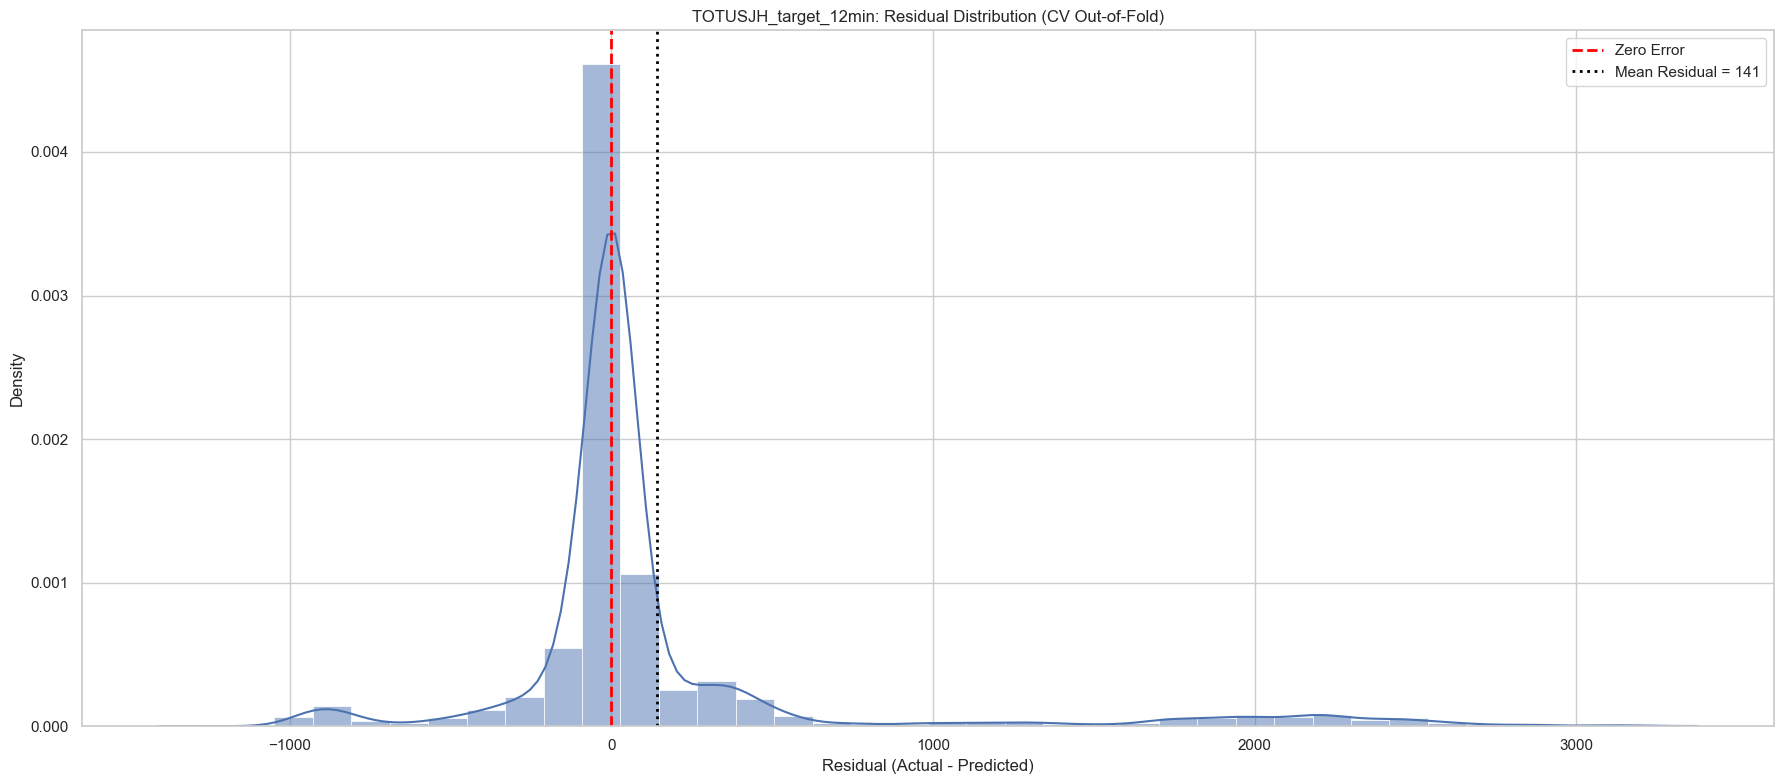


Running CV for TOTBSQ_target_12min
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47435
[LightGBM] [Info] Number of data points in the train set: 7197, number of used features: 187
[LightGBM] [Info] Start training from score 44045113192.612480
TOTBSQ_target_12min | Fold 1 | MAE: 7968181592.8444 | RMSE: 11444615277.4878 | R2: 0.6535 | NRMSE: 0.5886
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007059 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47439
[LightGBM] [Info] Number of data points in the train set: 14392, number of used features: 187
[LightGBM] [Info] Start training from score 44783198593.423012
TOTBSQ_target_12min | Fold 2 | MAE: 8051307080.5372 | RMSE: 18902779056.0825 | R2: 0.7341 | NRMSE: 0.5156
[LightGBM] [Info] Auto-choosing col-wise mult

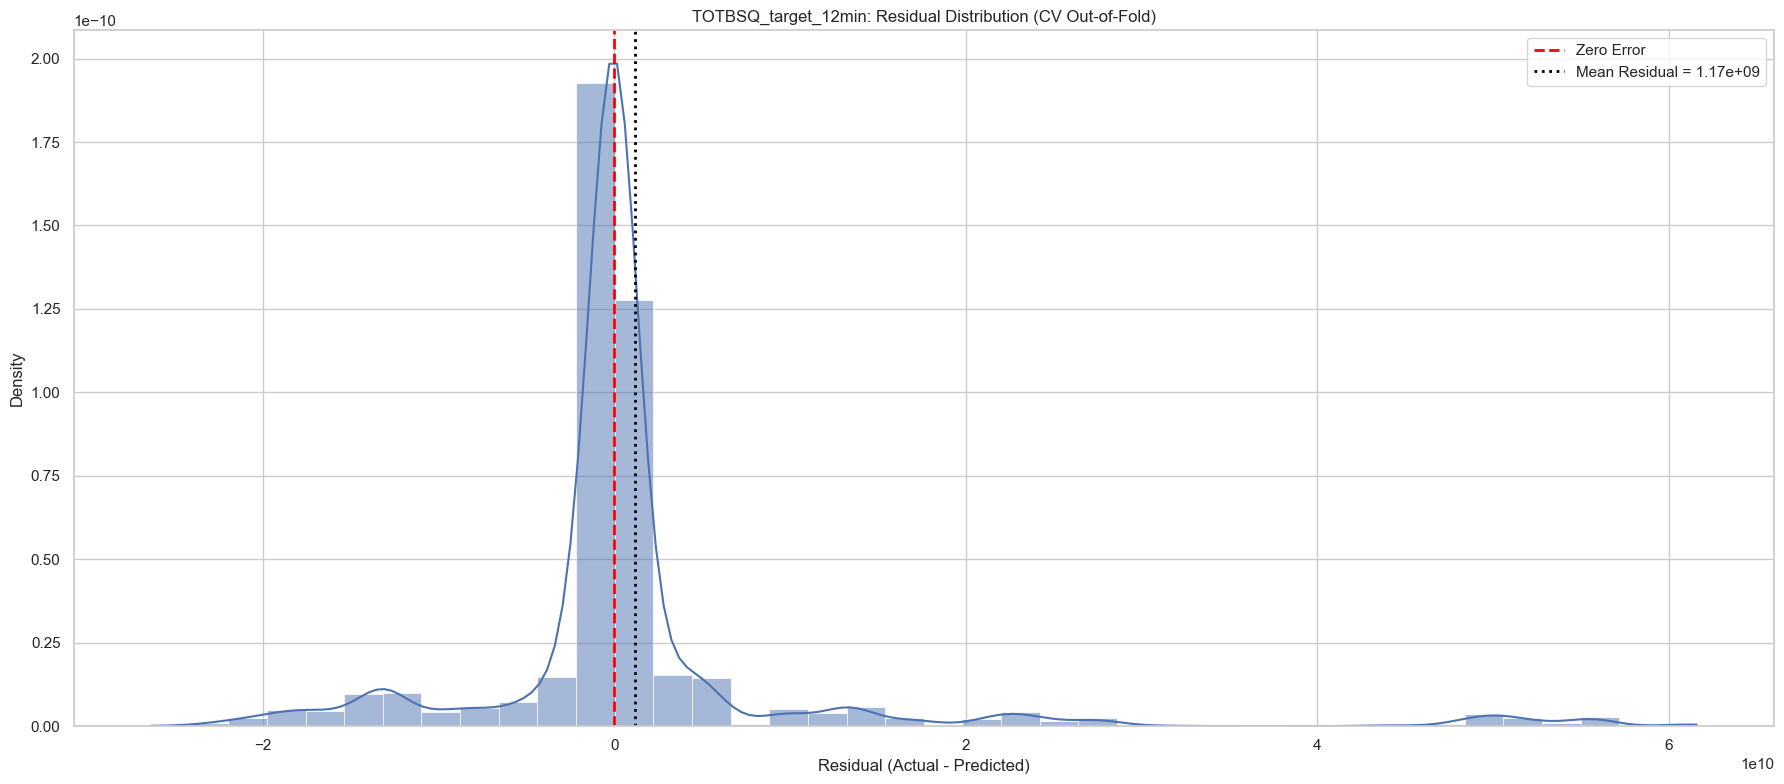


Running CV for TOTPOT_target_12min
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005874 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47435
[LightGBM] [Info] Number of data points in the train set: 7197, number of used features: 187
[LightGBM] [Info] Start training from score 817795890235592474099712.000000
TOTPOT_target_12min | Fold 1 | MAE: 166628283196926154768384.0000 | RMSE: 248562115556282659241984.0000 | R2: 0.5813 | NRMSE: 0.6470
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47439
[LightGBM] [Info] Number of data points in the train set: 14392, number of used features: 187
[LightGBM] [Info] Start training from score 820374910599779193978880.000000
TOTPOT_target_12min | Fold 2 | MAE: 133681020980124863954944.0000 | RMSE: 350305275760556866797568

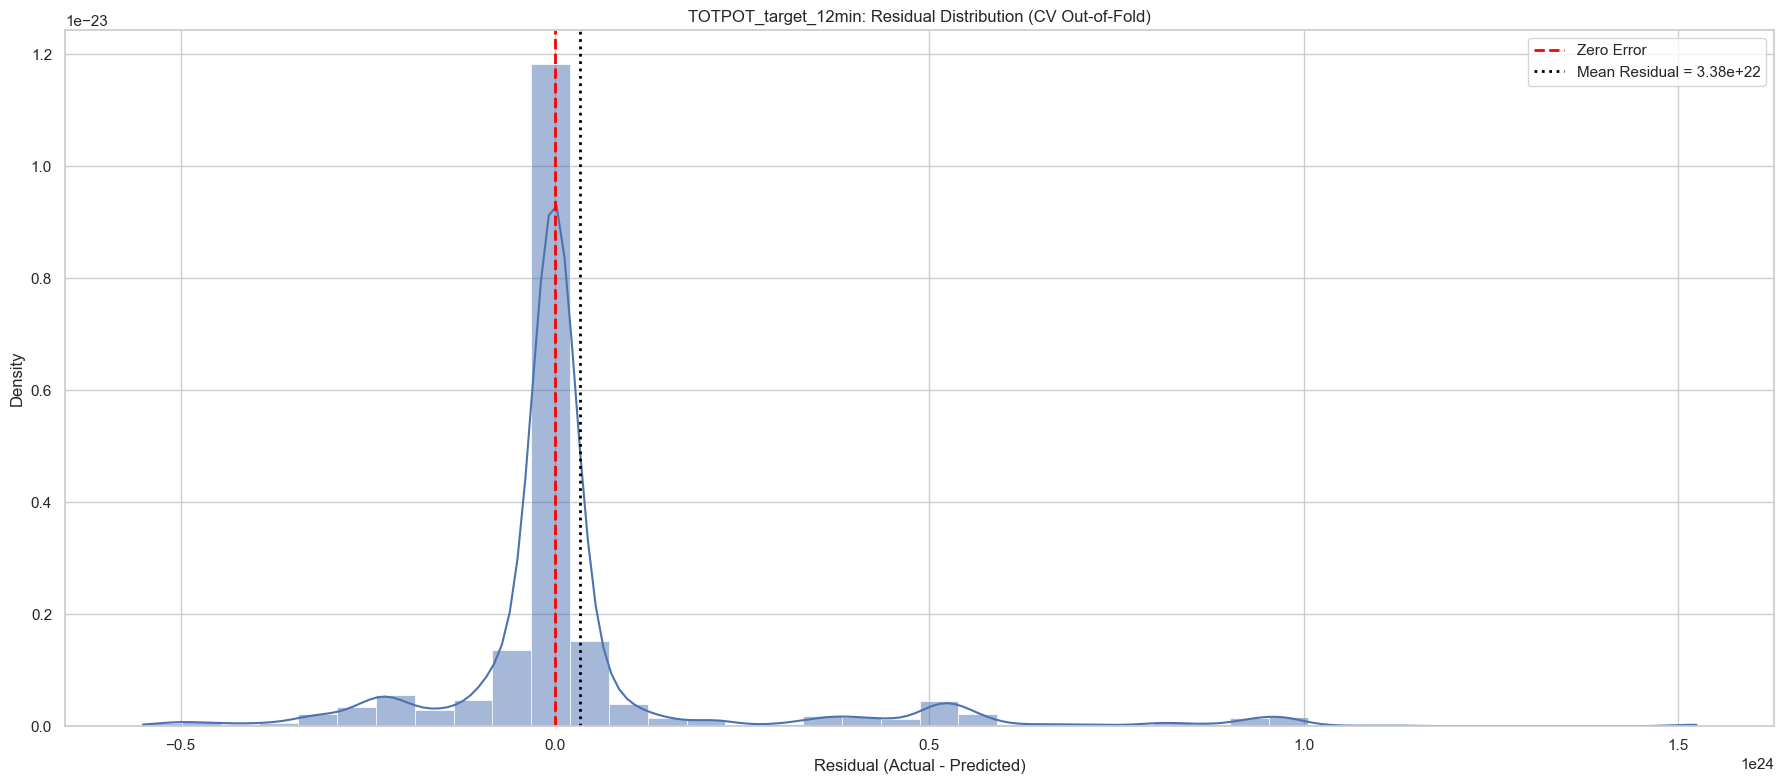


Running CV for TOTUSJZ_target_12min
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47435
[LightGBM] [Info] Number of data points in the train set: 7197, number of used features: 187
[LightGBM] [Info] Start training from score 58339826399558.960938
TOTUSJZ_target_12min | Fold 1 | MAE: 2835906376586.6206 | RMSE: 5239482300182.9619 | R2: 0.9376 | NRMSE: 0.2499
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47439
[LightGBM] [Info] Number of data points in the train set: 14392, number of used features: 187
[LightGBM] [Info] Start training from score 57835913342554.789062
TOTUSJZ_target_12min | Fold 2 | MAE: 7961185944127.6816 | RMSE: 18035481497240.5312 | R2: 0.7752 | NRMSE: 0.4741
[LightGBM] [Info] Auto-ch

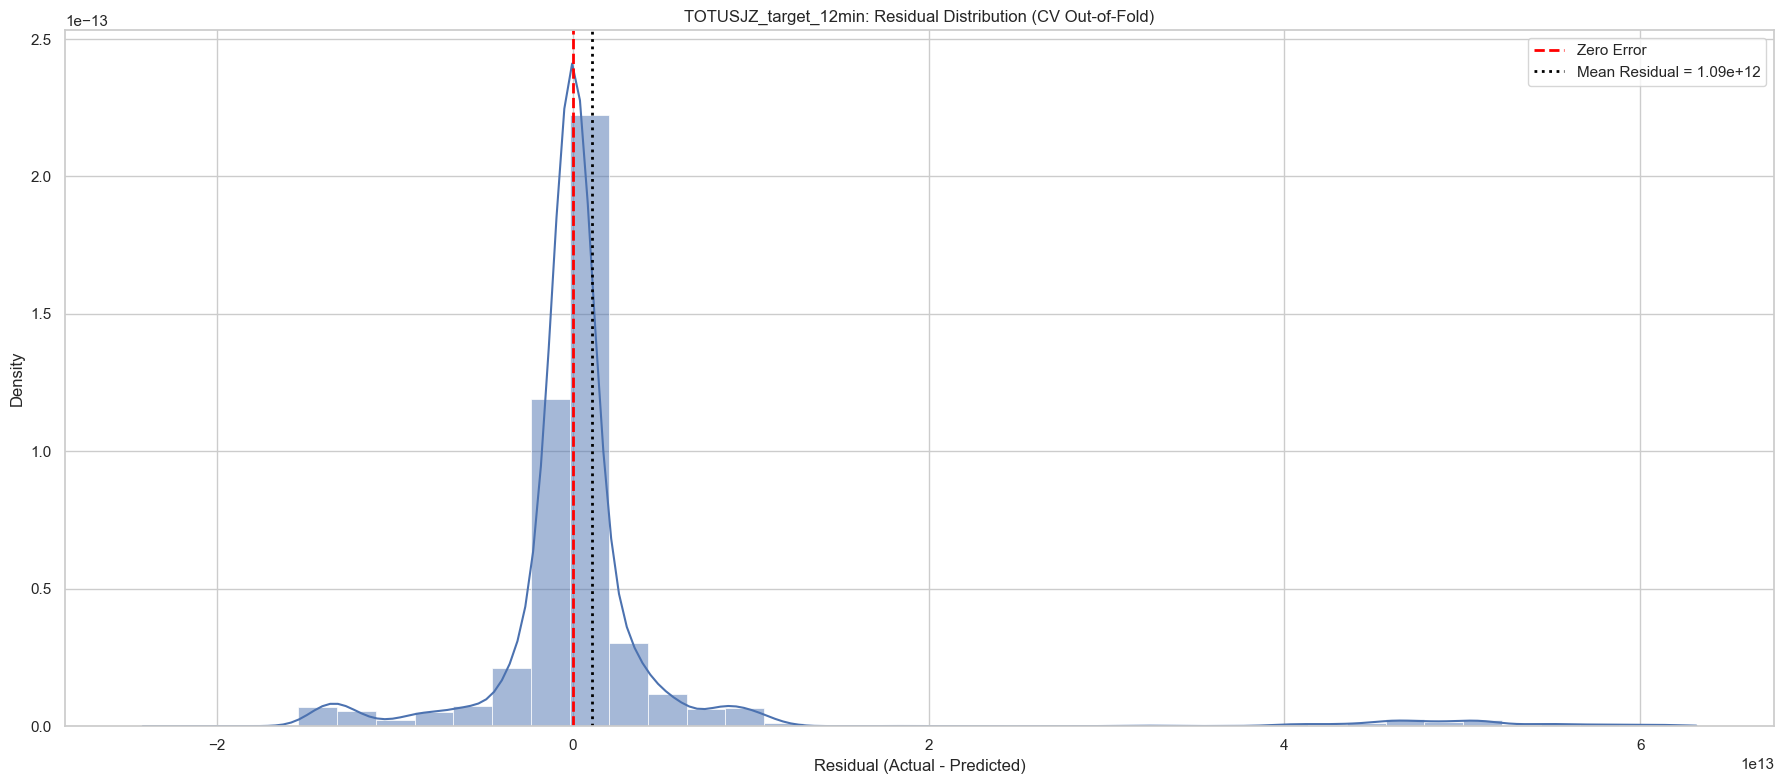


Running CV for ABSNJZH_target_12min
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007722 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47435
[LightGBM] [Info] Number of data points in the train set: 7197, number of used features: 187
[LightGBM] [Info] Start training from score 594.737913
ABSNJZH_target_12min | Fold 1 | MAE: 28.2603 | RMSE: 55.0339 | R2: 0.9628 | NRMSE: 0.1927
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008746 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47439
[LightGBM] [Info] Number of data points in the train set: 14392, number of used features: 187
[LightGBM] [Info] Start training from score 535.666940
ABSNJZH_target_12min | Fold 2 | MAE: 20.6412 | RMSE: 79.6998 | R2: 0.9625 | NRMSE: 0.1937
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.0121

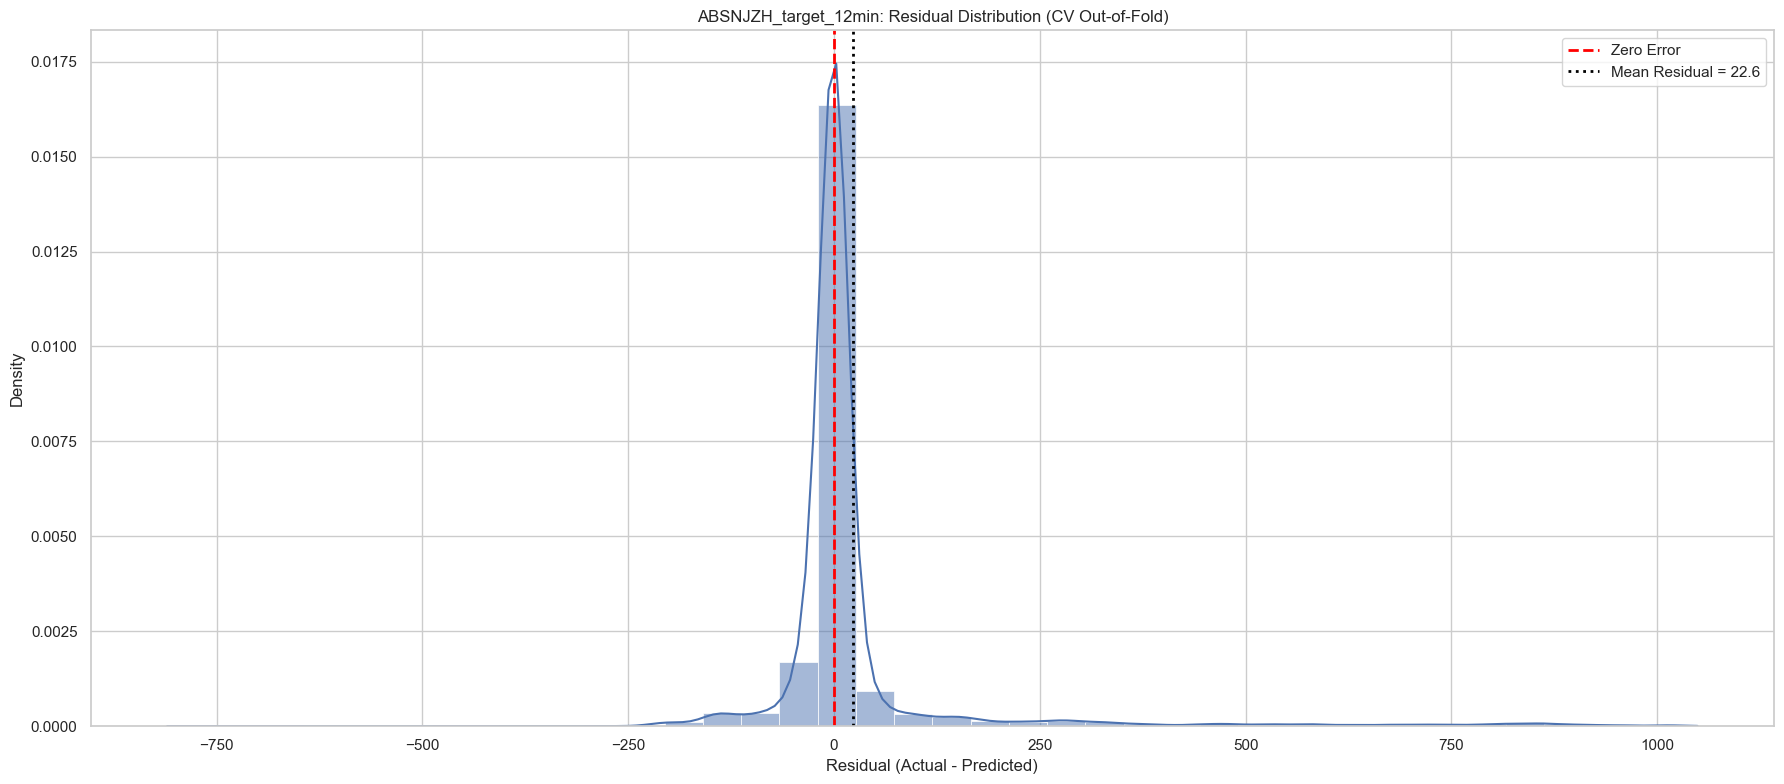


Running CV for R_VALUE_target_12min
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005507 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47435
[LightGBM] [Info] Number of data points in the train set: 7197, number of used features: 187
[LightGBM] [Info] Start training from score 4.764181
R_VALUE_target_12min | Fold 1 | MAE: 0.0129 | RMSE: 0.0192 | R2: 0.9971 | NRMSE: 0.0539
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47439
[LightGBM] [Info] Number of data points in the train set: 14392, number of used features: 187
[LightGBM] [Info] Start training from score 4.767034
R_VALUE_target_12min | Fold 2 | MAE: 0.0330 | RMSE: 0.1053 | R2: 0.9583 | NRMSE: 0.2043
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010496 secon

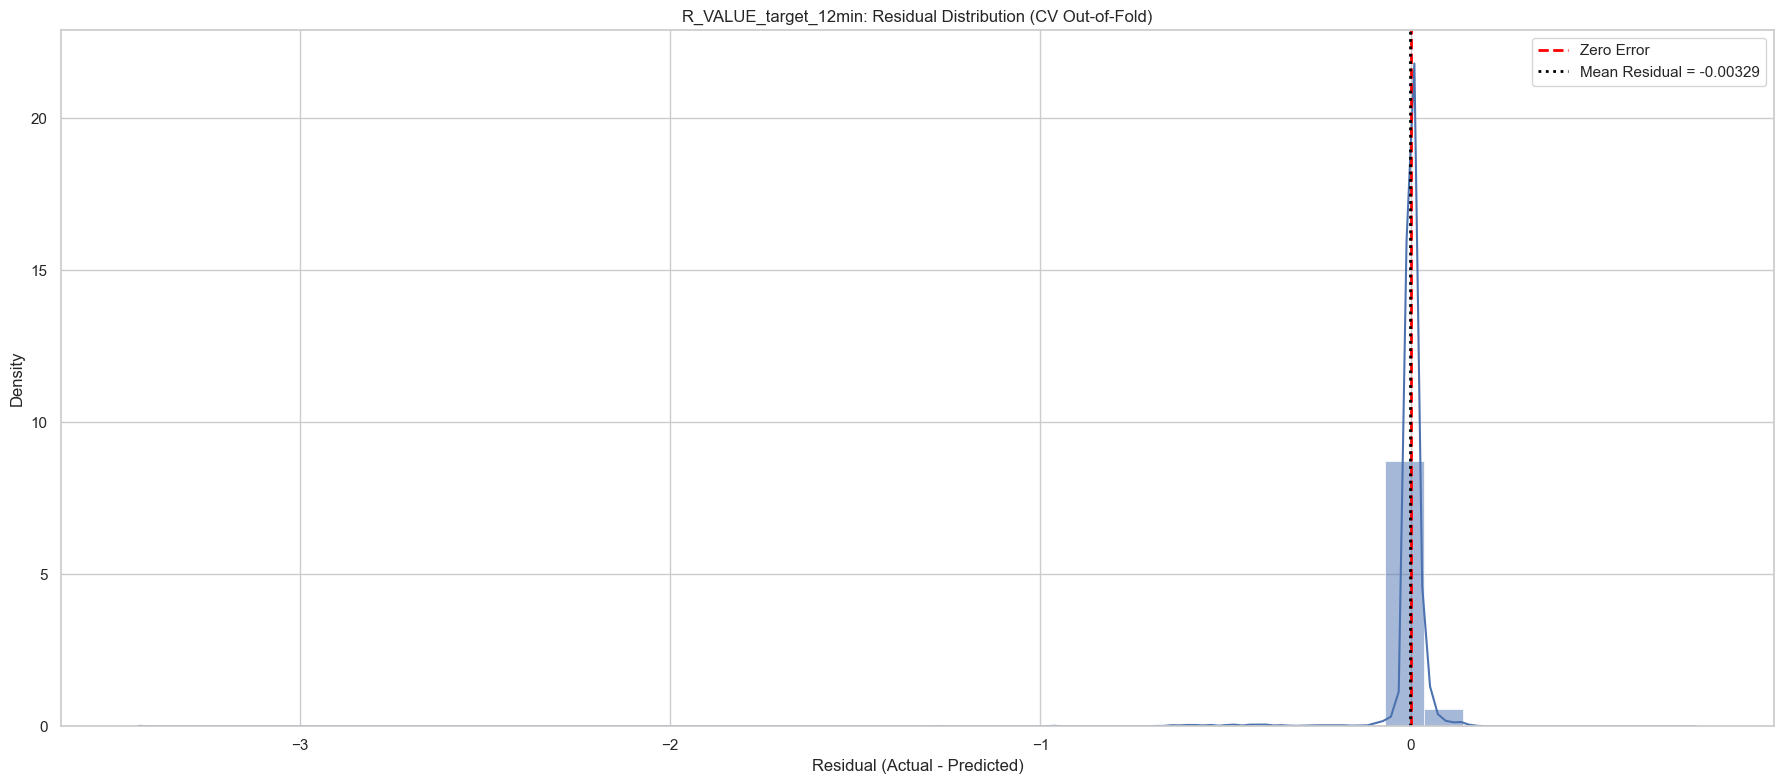

,Target,Mean_MAE,Mean_RMSE,Mean_NRMSE,Mean_R2,Std_RMSE,N_Features
5,R_VALUE,1.896306e-02,6.449828e-02,0.132704,0.970999,6.067581e-02,187
4,ABSNJZH,4.221184e+01,9.085545e+01,0.163938,0.962466,1.038525e+02,187
3,TOTUSJZ,2.981050e+12,6.118163e+12,0.184079,0.939963,6.795123e+12,187
0,TOTUSJH,2.557121e+02,4.700982e+02,0.230271,0.922605,4.260551e+02,187
1,TOTBSQ,4.435782e+09,8.005924e+09,0.265202,0.871087,7.771397e+09,187
2,TOTPOT,9.714476e+22,1.771572e+23,0.293431,0.855670,1.471844e+23,187


In [9]:

all_cv_results = {}
all_residuals = {}
all_models = {}
all_feature_cols = {}
summary_rows = []

for target in FEATURE_COLS:
    target_col = f"{target}_target_12min"

    print("\n" + "=" * 80)
    print(f"Running CV for {target_col}")
    print("=" * 80)

    model, cv_results, residual_df, feature_cols = crossval_with_residual_plot(
        train_df=train_df_copy,
        target_col=target_col,
        plot=True
    )

    all_cv_results[target] = cv_results
    all_residuals[target] = residual_df
    all_models[target] = model
    all_feature_cols[target] = feature_cols

    summary_rows.append({
        "Target": target,
        "Mean_MAE": cv_results["mae"].mean(),
        "Mean_RMSE": cv_results["rmse"].mean(),
        
        "Mean_NRMSE": cv_results["nrmse"].mean(),
        "Mean_R2": cv_results["r2"].mean(),
        "Std_RMSE": cv_results["rmse"].std(),
        "N_Features": len(feature_cols),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_NRMSE")
display(summary_df)

In [89]:
import plotly.figure_factory as ff 
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
def save_residual_distribution_plots_plotly(all_residuals,bins=40,show=False):
    
    saved_paths = {}

    for target in FEATURE_COLS:
        residual_df = all_residuals[target]
        residuals = residual_df["Residual"].dropna().values.astype(float).ravel()
        mean_resid = float(np.mean(residuals))
     

        fig = go.Figure()

        kde = gaussian_kde(residuals)
        x_range = np.linspace(residuals.min(), residuals.max(), 500)
        y_kde = kde(x_range)

        if target == "R_VAL":
            print("hi")

        fig.add_trace(
            go.Scatter(
                x=x_range,
                y=y_kde,
                mode="lines",
                name="Density",
                line=dict(width=2)
            )
        )

        fig.add_trace(
            go.Histogram(
                x=residuals,
                nbinsx=bins,
                histnorm="probability density",
                name="Residuals",
                marker=dict(color="rgba(152, 160, 251, 0.5)")
            )
        )

        # Zero line (red dashed)
        fig.add_trace(
            go.Scatter(
                x=[0, 0],
                y=[0, max(y_kde)*1.5],
                mode="lines",
                name="Zero Error",
                line=dict(color="red", dash="dash", width=2)
            )
        )

        # Mean line (black dotted)
        fig.add_trace(
            go.Scatter(
                x=[mean_resid, mean_resid],
                y=[0, max(y_kde)*1.5],
                mode="lines",
                name=f"Mean Residual = {mean_resid:.3g}",
                line=dict(color="black", dash="dot", width=2)
            )
        )

        fig.update_layout(
            title=f"{target}: Residual Distribution (CV Out-of-Fold)",
            xaxis_title="Residual (Actual - Predicted)",
            yaxis_title="Density",
            xaxis=dict(exponentformat="e",minexponent=4),  
            yaxis=dict(exponentformat="e",minexponent=4),
            template="plotly_white",
            width=1100,
            height=650,
            bargap=0.05,
            legend=dict(
                x=1,
                y=1,
                xanchor="right",
                yanchor="top",
                bgcolor="rgba(255,255,255,0.8)",
                bordercolor="lightgray",
                borderwidth=1
            )
        )

        output_path = os.path.join(f"../webapp/graphs/forecasts/{target}_residual_distribution.html")
        fig.write_html(output_path, full_html=False)
        saved_paths[target] = output_path

        print(f"Saved residual plot for {target} to {output_path}")

        if show:
            fig.show()

    return saved_paths

In [90]:
saved_residual_plots = save_residual_distribution_plots_plotly(all_residuals=all_residuals,show=False)

Saved residual plot for TOTUSJH to ../webapp/graphs/forecasts/TOTUSJH_residual_distribution.html
Saved residual plot for TOTBSQ to ../webapp/graphs/forecasts/TOTBSQ_residual_distribution.html
Saved residual plot for TOTPOT to ../webapp/graphs/forecasts/TOTPOT_residual_distribution.html
Saved residual plot for TOTUSJZ to ../webapp/graphs/forecasts/TOTUSJZ_residual_distribution.html
Saved residual plot for ABSNJZH to ../webapp/graphs/forecasts/ABSNJZH_residual_distribution.html
Saved residual plot for R_VALUE to ../webapp/graphs/forecasts/R_VALUE_residual_distribution.html


In [10]:
train_df

,Timestamp,active_region,TOTUSJH,TOTBSQ,TOTPOT,TOTUSJZ,ABSNJZH,R_VALUE,TOTUSJH_lag_1,TOTUSJH_lag_2,...,R_VALUE_roll_mean_6,R_VALUE_roll_std_6,R_VALUE_roll_mean_9,R_VALUE_roll_std_9,TOTUSJH_target_12min,TOTBSQ_target_12min,TOTPOT_target_12min,TOTUSJZ_target_12min,ABSNJZH_target_12min,R_VALUE_target_12min
0,2013-10-22 13:00:00,3295,2387.829011,4.165376e+10,7.788877e+23,4.726840e+13,555.531394,4.377963,NaN,NaN,...,NaN,NaN,NaN,NaN,2366.758849,4.160051e+10,7.791078e+23,4.711841e+13,564.539024,4.351804
1,2013-10-22 13:12:00,3295,2366.758849,4.160051e+10,7.791078e+23,4.711841e+13,564.539024,4.351804,2387.829011,NaN,...,4.377963,NaN,4.377963,NaN,2383.389072,4.165095e+10,7.808088e+23,4.704261e+13,571.158889,4.396680
2,2013-10-22 13:24:00,3295,2383.389072,4.165095e+10,7.808088e+23,4.704261e+13,571.158889,4.396680,2366.758849,2387.829011,...,4.364883,0.018497,4.364883,0.018497,2396.991954,4.176107e+10,7.833066e+23,4.739485e+13,585.576122,4.374243
3,2013-10-22 13:36:00,3295,2396.991954,4.176107e+10,7.833066e+23,4.739485e+13,585.576122,4.374243,2383.389072,2366.758849,...,4.375482,0.022541,4.375482,0.022541,2439.179219,4.181367e+10,7.830056e+23,4.831919e+13,603.161591,4.383397
4,2013-10-22 13:48:00,3295,2439.179219,4.181367e+10,7.830056e+23,4.831919e+13,603.161591,4.383397,2396.991954,2383.389072,...,4.375173,0.018415,4.375173,0.018415,2407.516554,4.182212e+10,7.830815e+23,4.777999e+13,612.060475,4.462635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71995,2014-03-30 10:00:00,3894,972.817065,1.042181e+10,1.227784e+23,1.911810e+13,9.238039,4.215885,967.434905,974.418162,...,4.173086,0.035138,4.184328,0.041245,989.085204,1.051527e+10,1.242006e+23,1.958661e+13,4.390075,4.161869
71996,2014-03-30 10:12:00,3894,989.085204,1.051527e+10,1.242006e+23,1.958661e+13,4.390075,4.161869,972.817065,967.434905,...,4.177164,0.038908,4.183222,0.040110,994.516196,1.056633e+10,1.244617e+23,1.987639e+13,7.554260,4.180376
71997,2014-03-30 10:24:00,3894,994.516196,1.056633e+10,1.244617e+23,1.987639e+13,7.554260,4.180376,989.085204,972.817065,...,4.175743,0.039358,4.173946,0.032963,980.008490,1.052681e+10,1.243420e+23,1.948072e+13,4.654857,4.183513
71998,2014-03-30 10:36:00,3894,980.008490,1.052681e+10,1.243420e+23,1.948072e+13,4.654857,4.183513,994.516196,989.085204,...,4.181905,0.036037,4.177405,0.031655,976.789367,1.050544e+10,1.242964e+23,1.932047e+13,4.660484,4.205279


Chosen file: M3.1@8424_Primary_ar4197_s2014-06-12T04_24_00_e2014-06-12T16_12_00.csv


c:\Users\astro\miniconda3\envs\SOLARFLARE\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\astro\miniconda3\envs\SOLARFLARE\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\astro\miniconda3\envs\SOLARFLARE\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\astro\miniconda3\envs\SOLARFLARE\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\astro\miniconda3\envs\SOLARFLARE\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor wa

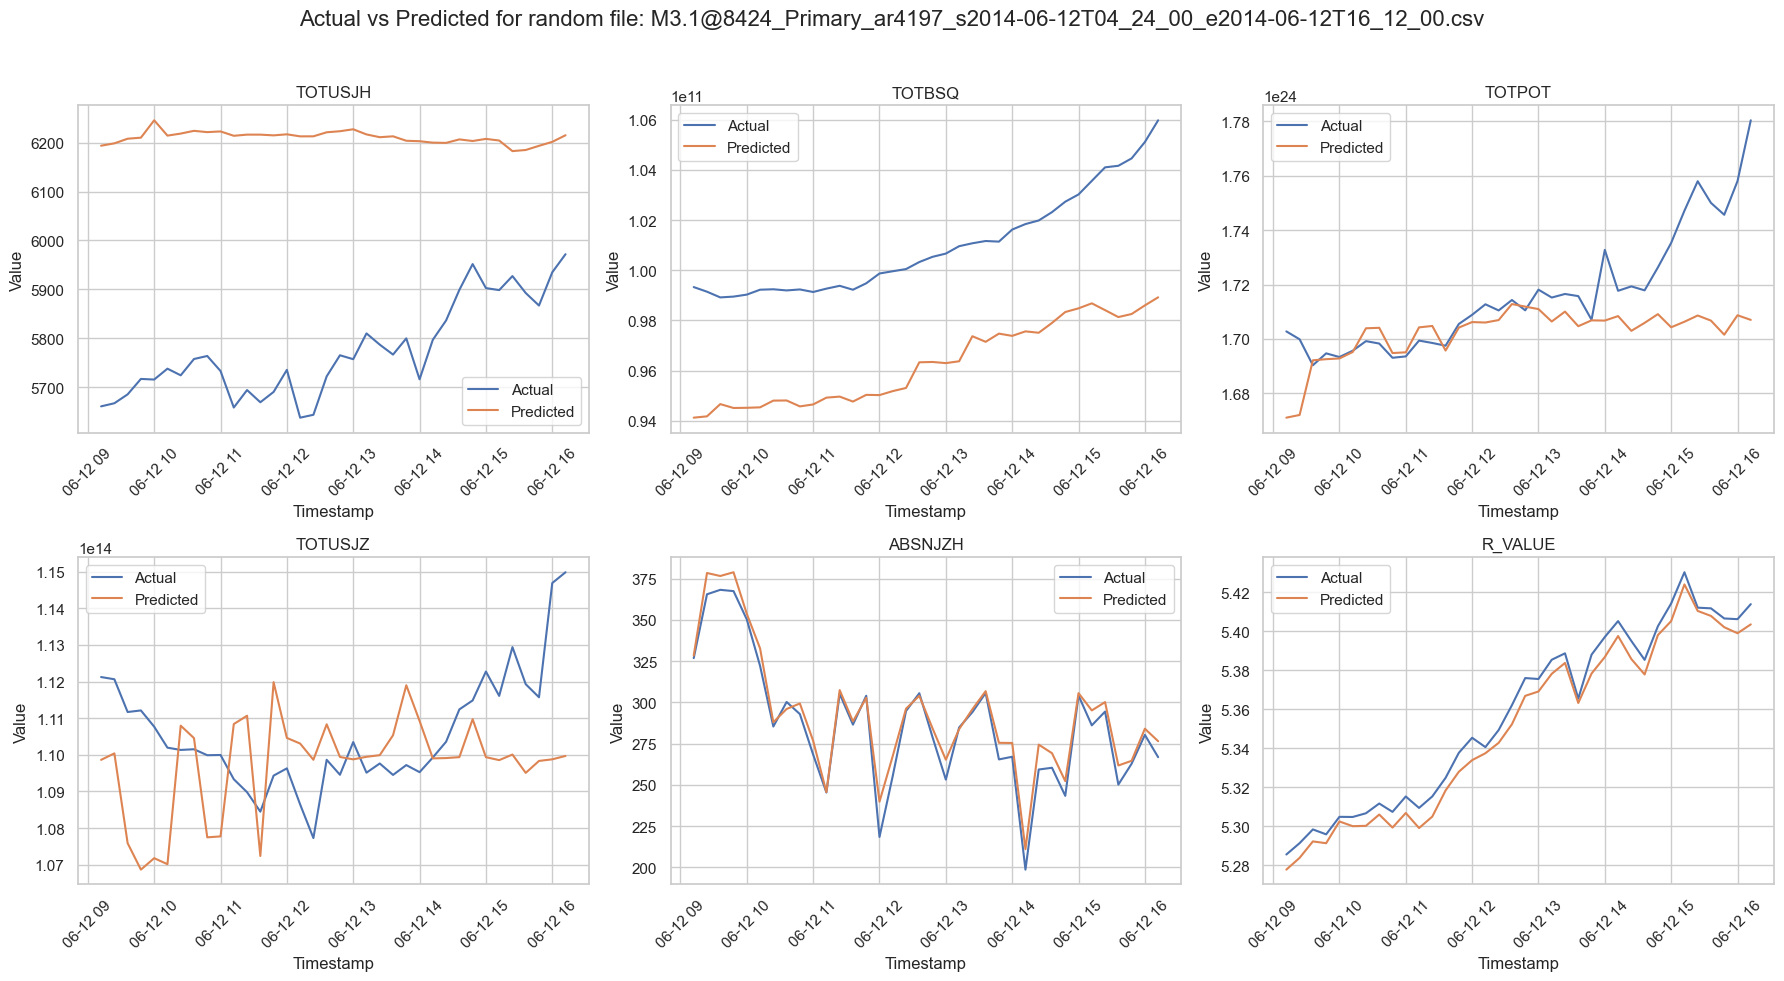

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

rng = np.random.default_rng()

available_files = test_df["source_file"].dropna().unique()
chosen_file = rng.choice(available_files)

print("Chosen file:", chosen_file)

file_df = (
    test_df[test_df["source_file"] == chosen_file]
    .copy()
    .sort_values("Timestamp")
    .reset_index(drop=True)
)

file_df["Timestamp"] = pd.to_datetime(file_df["Timestamp"])

pred_plot_frames = []

for target in FEATURE_COLS:
    target_col = f"{target}_target_12min"
    model = all_models[target]
    model_features = list(model.feature_name_)

    needed_cols = [c for c in model_features if c in file_df.columns] + [target_col, "Timestamp"]
    temp = file_df[needed_cols].copy()

    mask = temp[model_features].notna().all(axis=1) & temp[target_col].notna()
    temp = temp.loc[mask].copy()

    if len(temp) == 0:
        print(f"Skipping {target}: no valid rows")
        continue

    X_file = temp[model_features].copy()
    y_true = temp[target_col].copy()

    for col in X_file.columns:
        if isinstance(X_file[col].dtype, CategoricalDtype):
            X_file[col] = X_file[col].cat.codes
        elif X_file[col].dtype == "object":
            X_file[col] = pd.factorize(X_file[col])[0]
        elif X_file[col].dtype == "bool":
            X_file[col] = X_file[col].astype(int)
        elif np.issubdtype(X_file[col].dtype, np.datetime64):
            X_file[col] = X_file[col].view("int64")

    y_pred = model.predict(X_file.to_numpy())

    out = pd.DataFrame({
        "Timestamp": temp["Timestamp"].values,
        "Target": target,
        "Actual": y_true.values,
        "Predicted": y_pred,
        "Residual": y_true.values - y_pred,
    })

    pred_plot_frames.append(out)

pred_df = pd.concat(pred_plot_frames, ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, target in zip(axes, FEATURE_COLS):
    sub = pred_df[pred_df["Target"] == target].sort_values("Timestamp")

    if sub.empty:
        ax.set_title(f"{target} (no data)")
        ax.axis("off")
        continue

    ax.plot(sub["Timestamp"], sub["Actual"], label="Actual")
    ax.plot(sub["Timestamp"], sub["Predicted"], label="Predicted")
    ax.set_title(target)
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Value")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Actual vs Predicted for random file: {chosen_file}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

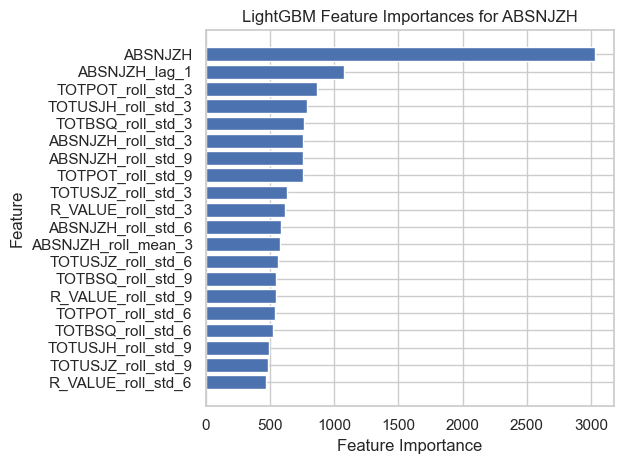

In [12]:
import matplotlib.pyplot as plt

# Get model + feature names
model = all_models['ABSNJZH']
feature_names = all_feature_cols['ABSNJZH']

# Build dataframe
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

# Plot
plt.figure()
plt.barh(fi_df["Feature"], fi_df["Importance"])
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importances for ABSNJZH")
plt.tight_layout()
plt.show()

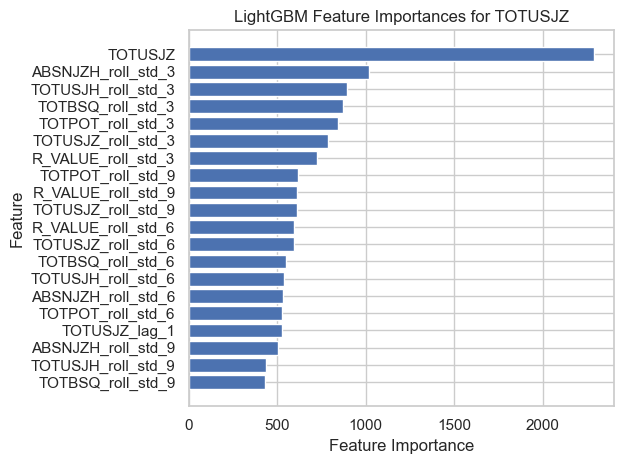

In [13]:
# Get model + feature names
model = all_models['TOTUSJZ']
feature_names = all_feature_cols['TOTUSJZ']

# Build dataframe
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

# Plot
plt.figure()
plt.barh(fi_df["Feature"], fi_df["Importance"])
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importances for TOTUSJZ")
plt.tight_layout()
plt.show()

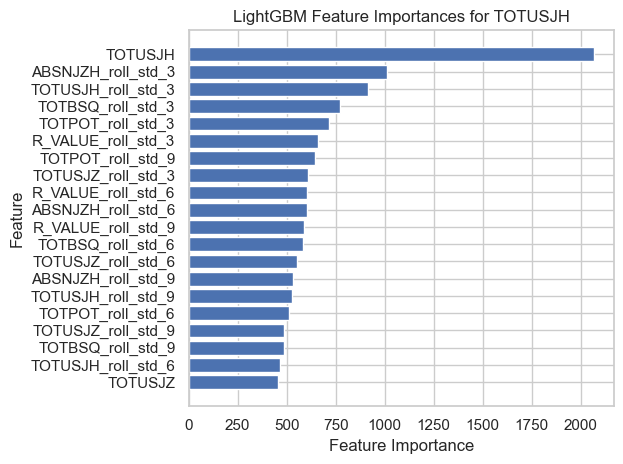

In [14]:
# Get model + feature names
model = all_models['TOTUSJH']
feature_names = all_feature_cols['TOTUSJH']

# Build dataframe
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

# Plot
plt.figure()
plt.barh(fi_df["Feature"], fi_df["Importance"])
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importances for TOTUSJH")
plt.tight_layout()
plt.show()

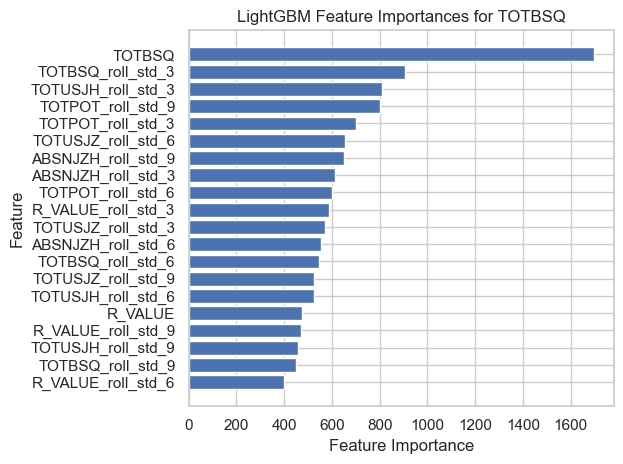

In [15]:
# Get model + feature names
model = all_models['TOTBSQ']
feature_names = all_feature_cols['TOTBSQ']

# Build dataframe
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

# Plot
plt.figure()
plt.barh(fi_df["Feature"], fi_df["Importance"])
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importances for TOTBSQ")
plt.tight_layout()
plt.show()

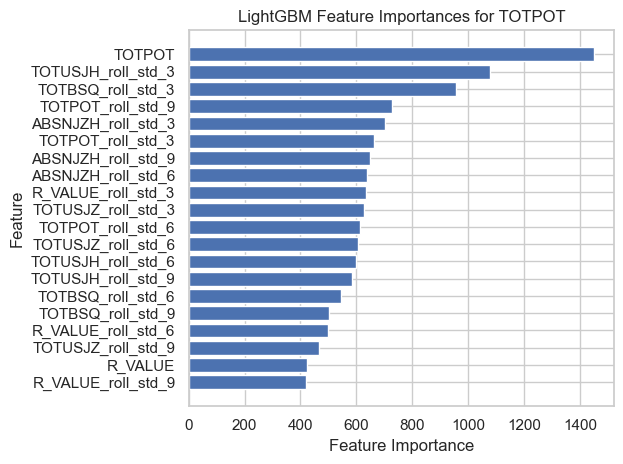

In [16]:
# Get model + feature names
model = all_models['TOTPOT']
feature_names = all_feature_cols['TOTPOT']

# Build dataframe
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

# Plot
plt.figure()
plt.barh(fi_df["Feature"], fi_df["Importance"])
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importances for TOTPOT")
plt.tight_layout()
plt.show()

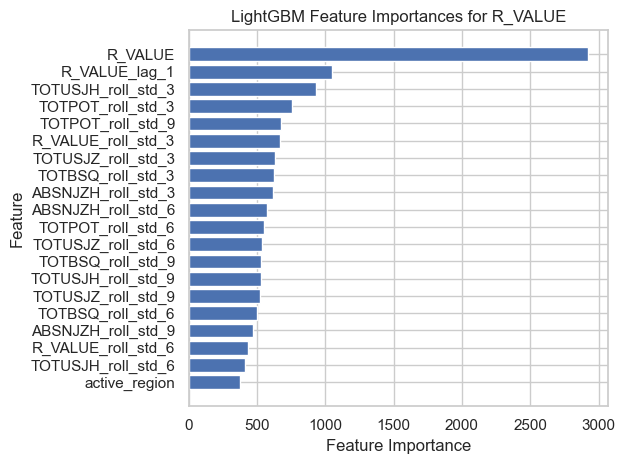

In [17]:
# Get model + feature names
model = all_models['R_VALUE']
feature_names = all_feature_cols['R_VALUE']

# Build dataframe
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

# Plot
plt.figure()
plt.barh(fi_df["Feature"], fi_df["Importance"])
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importances for R_VALUE")
plt.tight_layout()
plt.show()

In [18]:
import plotly.express as px

target = "TOTUSJH"

def mpl_to_plotly(target):

    fi_df = pd.DataFrame({
        "Feature": all_feature_cols[target],
        "Importance": all_models[target].feature_importances_
    }).sort_values("Importance", ascending=False).head(20)

    # reverse for top-to-bottom descending display
    fi_df = fi_df.iloc[::-1]

    fi_df.to_csv(f"../data/{target}_feature_importance.csv")

    fig = px.bar(
        fi_df,
        x="Importance",
        y="Feature",
        orientation="h",
        title=f"Top 20 LightGBM Feature Importances for {target}",
        text="Importance"
    )

    fig.update_traces(
        texttemplate="%{text}",
        textposition="outside"
    )

    fig.update_layout(
        height=700,
        width=950,
        xaxis_title="Feature Importance",
        yaxis_title="Feature",
        template="plotly_white"
    )

    fig.show()
    fig.write_html(f"../webapp/graphs/forecasts/{target}.html",full_html=False)

# mpl_to_plotly(target)

In [20]:
TARGETS

for targ in TARGETS:
    mpl_to_plotly(targ)

In [ ]:
summary_df.to_csv("../data/forecastmodel_summary.csv")

In [ ]:
test_df["source_file"]

0        M6.5@7994:Primary_ar3941_s2014-04-01T09:24:00_...
1        M6.5@7994:Primary_ar3941_s2014-04-01T09:24:00_...
2        M6.5@7994:Primary_ar3941_s2014-04-01T09:24:00_...
3        M6.5@7994:Primary_ar3941_s2014-04-01T09:24:00_...
4        M6.5@7994:Primary_ar3941_s2014-04-01T09:24:00_...
                               ...                        
13435    M1.1@8445:Primary_ar4197_s2014-06-14T00:24:00_...
13436    M1.1@8445:Primary_ar4197_s2014-06-14T00:24:00_...
13437    M1.1@8445:Primary_ar4197_s2014-06-14T00:24:00_...
13438    M1.1@8445:Primary_ar4197_s2014-06-14T00:24:00_...
13439    M1.1@8445:Primary_ar4197_s2014-06-14T00:24:00_...
Name: source_file, Length: 13440, dtype: object

In [ ]:
test_df["source_file"]

0        M6.5@7994:Primary_ar3941_s2014-04-01T09:24:00_...
1        M6.5@7994:Primary_ar3941_s2014-04-01T09:24:00_...
2        M6.5@7994:Primary_ar3941_s2014-04-01T09:24:00_...
3        M6.5@7994:Primary_ar3941_s2014-04-01T09:24:00_...
4        M6.5@7994:Primary_ar3941_s2014-04-01T09:24:00_...
                               ...                        
13435    M1.1@8445:Primary_ar4197_s2014-06-14T00:24:00_...
13436    M1.1@8445:Primary_ar4197_s2014-06-14T00:24:00_...
13437    M1.1@8445:Primary_ar4197_s2014-06-14T00:24:00_...
13438    M1.1@8445:Primary_ar4197_s2014-06-14T00:24:00_...
13439    M1.1@8445:Primary_ar4197_s2014-06-14T00:24:00_...
Name: source_file, Length: 13440, dtype: object

In [21]:
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_model(train_df, test_df, target_col):
    feature_cols = [
        c for c in train_df.columns
        if c not in [target_col, "Timestamp", "source_file"] and "_target_" not in c
    ]

    # Training data
    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].copy()

    if "active_region" in X_train.columns:
        X_train["active_region"] = X_train["active_region"].astype("category")

    train_mask = X_train.notna().all(axis=1) & y_train.notna()
    X_train = X_train.loc[train_mask].reset_index(drop=True)
    y_train = y_train.loc[train_mask].reset_index(drop=True)

    # test data
    X_test = test_df[feature_cols].copy()
    y_test = test_df[target_col].copy()

    if "active_region" in X_test.columns:
        X_test["active_region"] = X_test["active_region"].astype("category")

    eval_mask = X_test.notna().all(axis=1) & y_test.notna()
    X_test = X_test.loc[eval_mask].reset_index(drop=True)
    y_test = y_test.loc[eval_mask].reset_index(drop=True)

    # Train model
    model = LGBMRegressor(
        objective="regression",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train,
        categorical_feature=["active_region"] if "active_region" in X_train.columns else "auto"
    )

    #preds
    y_pred = model.predict(X_test)

    # model Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    nrmse = rmse / y_test.std() if y_test.std() > 0 else np.nan

    print(f"Target: {target_col}")
    print(f"MAE:   {mae:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"R2:    {r2:.4f}")
    print(f"NRMSE: {nrmse:.4f}")

    return model, y_pred, feature_cols

train_model(train_df=train_df,test_df=test_df,target_col="R_VALUE")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020822 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47203
[LightGBM] [Info] Number of data points in the train set: 43200, number of used features: 186
[LightGBM] [Info] Start training from score 4.772241
Target: R_VALUE
MAE:   0.0311
RMSE:  0.0586
R2:    0.9843
NRMSE: 0.1255


(LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
               n_jobs=-1, objective='regression', random_state=42,
               subsample=0.8),
 array([4.49686103, 4.49032577, 4.5148551 , ..., 5.65936032, 5.66316238,
        5.66264589], shape=(8064,)),
 ['active_region',
  'TOTUSJH',
  'TOTBSQ',
  'TOTPOT',
  'TOTUSJZ',
  'ABSNJZH',
  'TOTUSJH_lag_1',
  'TOTUSJH_lag_2',
  'TOTUSJH_lag_3',
  'TOTUSJH_lag_4',
  'TOTUSJH_lag_5',
  'TOTUSJH_lag_6',
  'TOTUSJH_lag_7',
  'TOTUSJH_lag_8',
  'TOTUSJH_lag_9',
  'TOTUSJH_lag_10',
  'TOTUSJH_lag_11',
  'TOTUSJH_lag_12',
  'TOTUSJH_lag_13',
  'TOTUSJH_lag_14',
  'TOTUSJH_lag_15',
  'TOTUSJH_lag_16',
  'TOTUSJH_lag_17',
  'TOTUSJH_lag_18',
  'TOTUSJH_lag_19',
  'TOTUSJH_lag_20',
  'TOTUSJH_lag_21',
  'TOTUSJH_lag_22',
  'TOTUSJH_lag_23',
  'TOTUSJH_lag_24',
  'TOTBSQ_lag_1',
  'TOTBSQ_lag_2',
  'TOTBSQ_lag_3',
  'TOTBSQ_lag_4',
  'TOTBSQ_lag_5',
  'TOTBSQ_lag_6',
  'TOTBSQ_lag_7',
  'TOTBSQ_lag_8',
  'TOTBSQ_lag_9',
 

In [22]:
import joblib

for target in FEATURE_COLS:
    print(f"\nTraining model for: {target}")
    model, y_pred, feature_cols = train_model(train_df, test_df, target)
    joblib.dump(model, f"../models/LightGBMForecasters/{target}_lgbm.pkl")
    print(f"Saved model in ../models/LightGBMForecasters/{target}_lgbm.pkl")


Training model for: TOTUSJH
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47203
[LightGBM] [Info] Number of data points in the train set: 43200, number of used features: 186
[LightGBM] [Info] Start training from score 3791.482291
Target: TOTUSJH
MAE:   52.0659
RMSE:  116.1702
R2:    0.9943
NRMSE: 0.0757
Saved model in ../models/LightGBMForecasters/TOTUSJH_lgbm.pkl

Training model for: TOTBSQ
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015355 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47203
[LightGBM] [Info] Number of data points in the train set: 43200, number of used features: 186
[LightGBM] [Info] Start training from score 52226511855.893333
Target: TOTBSQ
MAE:   1057420473.5691
RMSE:  2003763601.9350
R2:    0.9956
NRMSE: 0.0660
Saved model in .